In [1]:
import os, shutil, random
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
from PIL import Image
from tensorflow.keras import layers




# Mount Drive
drive.mount('/content/drive')
DRIVE_BASE = '/content/drive/MyDrive/irrigation_ml'

# Kaggle auth — update token_file to your own
token_file = f'{DRIVE_BASE}/kaggle_token.txt'
# token_file = f'{DRIVE_BASE}/kaggle_token_friend.txt'  # friend: uncomment this line

with open(token_file) as f:
    os.environ['KAGGLE_API_TOKEN'] = f.read().strip()

!pip install kaggle --quiet

# Verify GPU
import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print("Setup complete")

Mounted at /content/drive
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Setup complete


In [2]:

PLANTVILLAGE_DIR = '/content/plantvillage'
IP102_DIR        = '/content/ip102'

# Only download if not already present (saves time if cell is re-run)
if not os.path.exists(PLANTVILLAGE_DIR):
    print("Downloading PlantVillage (~1.2GB)...")
    !kaggle datasets download -d abdallahalidev/plantvillage-dataset \
        --unzip -p {PLANTVILLAGE_DIR} -q
    print("PlantVillage done")
else:
    print("PlantVillage already downloaded")

if not os.path.exists(IP102_DIR):
    print("Downloading IP102 (~2GB)...")
    !kaggle datasets download -d rtlmhjbn/ip02-dataset \
        --unzip -p {IP102_DIR} -q
    print("IP102 done")
else:
    print("IP102 already downloaded")

# Show what we got
pv_folders = [d for d in os.listdir(PLANTVILLAGE_DIR)
              if os.path.isdir(f'{PLANTVILLAGE_DIR}/{d}')]
print(f"\nPlantVillage folders found: {len(pv_folders)}")
print("First 5:", pv_folders[:5])

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
PlantVillage done
Dataset URL: https://www.kaggle.com/datasets/rtlmhjbn/ip02-dataset
License(s): copyright-authors
IP102 done

PlantVillage folders found: 1
First 5: ['plantvillage dataset']


In [3]:
# Correct paths now that we know the structure
PLANTVILLAGE_BASE = '/content/plantvillage/plantvillage dataset/color'
IP102_TRAIN_DIR   = '/content/ip102/classification/train'
OUTPUT_DIR        = '/content/dataset'

CLASS_MAP = {
    'Healthy': [
        'Pepper,_bell___healthy',
        'Potato___healthy',
        'Tomato___healthy',
    ],
    'Early_Blight': [
        'Potato___Early_blight',
        'Tomato___Early_blight',
    ],
    'Late_Blight': [
        'Potato___Late_blight',
        'Tomato___Late_blight',
    ],
    'Nutrient_Deficiency': [
        'Tomato___Leaf_Mold',
        'Tomato___Target_Spot',
        'Tomato___Tomato_mosaic_virus',
        'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    ],
    'Pest': [],  # filled from IP102 below
}

MAX_PEST = 2500

# Verify the base path works
available = os.listdir(PLANTVILLAGE_BASE)
print(f"PlantVillage color folders: {len(available)}")
print("First 5:", available[:5])

# Check our CLASS_MAP folders actually exist
print("\nVerifying CLASS_MAP folders:")
for cls, folders in CLASS_MAP.items():
    for f in folders:
        exists = f in available
        status = "OK" if exists else "MISSING"
        print(f"  [{status}] {f}")

PlantVillage color folders: 38
First 5: ['Grape___Black_rot', 'Orange___Haunglongbing_(Citrus_greening)', 'Raspberry___healthy', 'Tomato___Bacterial_spot', 'Potato___Early_blight']

Verifying CLASS_MAP folders:
  [OK] Pepper,_bell___healthy
  [OK] Potato___healthy
  [OK] Tomato___healthy
  [OK] Potato___Early_blight
  [OK] Tomato___Early_blight
  [OK] Potato___Late_blight
  [OK] Tomato___Late_blight
  [OK] Tomato___Leaf_Mold
  [OK] Tomato___Target_Spot
  [OK] Tomato___Tomato_mosaic_virus
  [OK] Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [4]:

MAX_PER_CLASS = 2500
copied = defaultdict(int)
warnings = []

# ─────────────────────────────
# Create output folders
# ─────────────────────────────
for cls in CLASS_MAP:
    os.makedirs(Path(OUTPUT_DIR) / cls, exist_ok=True)

# ─────────────────────────────
# PlantVillage
# ─────────────────────────────
print("Copying PlantVillage images...")

for target_class, source_folders in CLASS_MAP.items():

    all_imgs = []

    for folder in source_folders:
        src = Path(PLANTVILLAGE_BASE) / folder

        if not src.exists():
            warnings.append(f"NOT FOUND: {folder}")
            continue

        all_imgs.extend(src.glob("*.jpg"))
        all_imgs.extend(src.glob("*.JPG"))
        all_imgs.extend(src.glob("*.png"))

    # shuffle + global cap per class
    random.shuffle(all_imgs)
    all_imgs = all_imgs[:MAX_PER_CLASS]

    for img in all_imgs:
        dst = Path(OUTPUT_DIR) / target_class / img.name

        if not dst.exists():
            shutil.copy(img, dst)
            copied[target_class] += 1

    print(f"[PlantVillage] {target_class}: {copied[target_class]} images")

# ─────────────────────────────
# IP102
# ─────────────────────────────
print("\nScanning IP102 images...")

ip102_lookup = {}

for class_folder in os.listdir(IP102_TRAIN_DIR):
    class_path = Path(IP102_TRAIN_DIR) / class_folder

    if class_path.is_dir():
        for img in class_path.glob("*.jpg"):
            ip102_lookup[img.name] = img

print(f"IP102 images found: {len(ip102_lookup)}")

matched = []

with open("/content/ip102/train.txt") as f:
    for line in f:
        parts = line.strip().split()
        if parts and parts[0] in ip102_lookup:
            matched.append(ip102_lookup[parts[0]])

print(f"Matched from train.txt: {len(matched)}")

random.shuffle(matched)
matched = matched[:MAX_PER_CLASS]

for img in matched:
    dst = Path(OUTPUT_DIR) / "Pest" / img.name

    if not dst.exists():
        shutil.copy(img, dst)
        copied["Pest"] += 1

print(f"Pest images copied: {copied['Pest']}")

# ─────────────────────────────
# Report
# ─────────────────────────────
print("\n=== Warnings ===")
if warnings:
    for w in warnings:
        print(" ", w)
else:
    print("  None — all folders found")

print("\n=== Final class balance ===")

total = 0
for cls in sorted(copied):
    n = copied[cls]
    total += n
    bar = "█" * (n // 200)
    print(f"  {cls:<22} {n:>5}  {bar}")

print(f"\nTotal: {total} images")

Copying PlantVillage images...
[PlantVillage] Healthy: 2500 images
[PlantVillage] Early_Blight: 2000 images
[PlantVillage] Late_Blight: 2500 images
[PlantVillage] Nutrient_Deficiency: 2500 images
[PlantVillage] Pest: 0 images

Scanning IP102 images...
IP102 images found: 45095
Matched from train.txt: 45095
Pest images copied: 2500

=== Warnings ===
  None — all folders found

=== Final class balance ===
  Early_Blight            2000  ██████████
  Healthy                 2500  ████████████
  Late_Blight             2500  ████████████
  Nutrient_Deficiency     2500  ████████████
  Pest                    2500  ████████████

Total: 12000 images


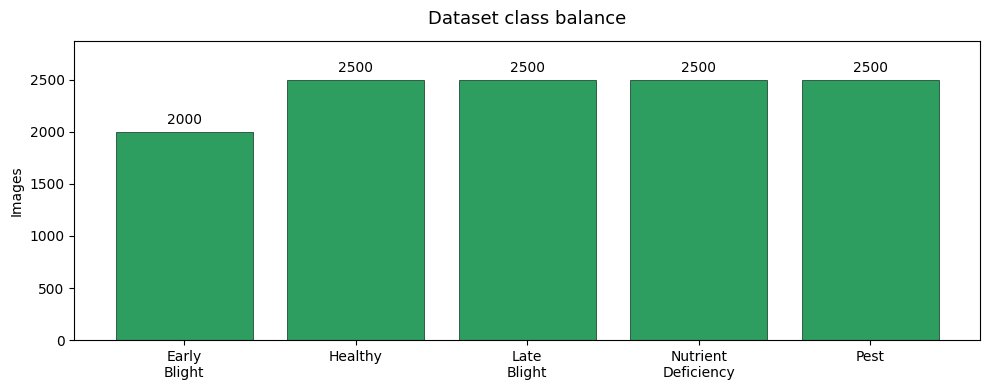

Chart saved to Drive


In [5]:

classes = []
counts  = []

for cls in sorted(os.listdir(OUTPUT_DIR)):
    path = Path(OUTPUT_DIR) / cls

    if not path.is_dir():
        continue

    n = len([
        f for f in path.rglob("*")
        if f.is_file()
    ])

    classes.append(cls.replace('_', '\n'))
    counts.append(n)

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    classes,
    counts,
    color='#2d9e5f',
    edgecolor='#0a2e1a',
    linewidth=0.5
)

ax.set_title('Dataset class balance', fontsize=13, pad=12)
ax.set_ylabel('Images')

if counts:
    ax.set_ylim(0, max(counts) * 1.15)

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        str(count),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/class_balance.png', dpi=120)
plt.show()

print("Chart saved to Drive")

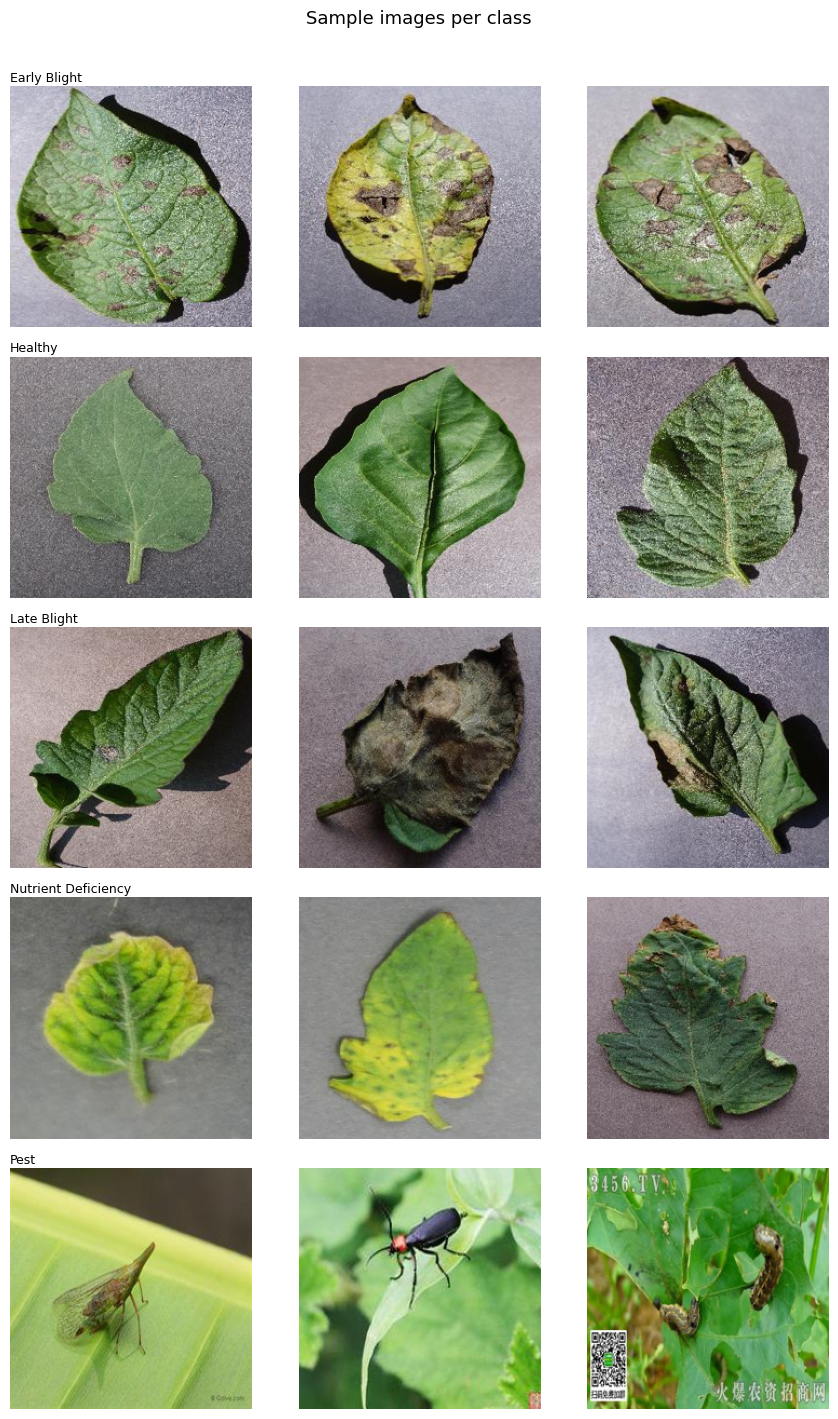

Samples saved to Drive


In [6]:

fig, axes = plt.subplots(len(os.listdir(OUTPUT_DIR)), 3, figsize=(9, 14))
fig.suptitle('Sample images per class', fontsize=13, y=1.01)

for row, cls in enumerate(sorted(os.listdir(OUTPUT_DIR))):
    imgs = [p for p in Path(f'{OUTPUT_DIR}/{cls}').iterdir()
        if p.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    samples = random.sample(imgs, min(3, len(imgs)))
    for col, img_path in enumerate(samples):
        img = Image.open(img_path).resize((224, 224))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls.replace('_', ' '),
                                     fontsize=9, loc='left', pad=3)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print("Samples saved to Drive")

In [7]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42  # CRITICAL: Seed must be identical for both splits
NUM_CLASSES = 5

# 1. Load ONLY the Training Set (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2, # 20% reserved for val/test
    subset="training",    # Pull the training portion
    seed=SEED,            # Seed ensures the split is identical
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)

# 2. Load the Validation/Test Pool (The remaining 20%)
val_test_pool = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2,
    subset="validation",  # Pull the unseen portion
    seed=SEED,            # Must exactly match the train_ds seed!
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)

# 3. Split the 20% pool exactly in half to get 10% Val / 10% Test
# Because shuffle=True by default in the loader, we can safely take/skip here
# WITHOUT reshuffling issues, as long as we don't re-iterate the base pool randomly.
val_batches = len(val_test_pool) // 2
val_ds  = val_test_pool.take(val_batches)
test_ds = val_test_pool.skip(val_batches)

print(f"Train: {len(train_ds)} batches")
print(f"Val:   {len(val_ds)} batches")
print(f"Test:  {len(test_ds)} batches")

# 4. Performance Tuning
AUTOTUNE = tf.data.AUTOTUNE

# Add an explicit .shuffle() to train_ds AFTER caching.
# This shuffles the batches dynamically in memory every epoch,
# which is vastly superior for preventing overfitting.
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

# Validation and Test should NOT be shuffled
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 12000 files belonging to 5 classes.
Using 9600 files for training.
Found 12000 files belonging to 5 classes.
Using 2400 files for validation.
Train: 300 batches
Val:   37 batches
Test:  38 batches


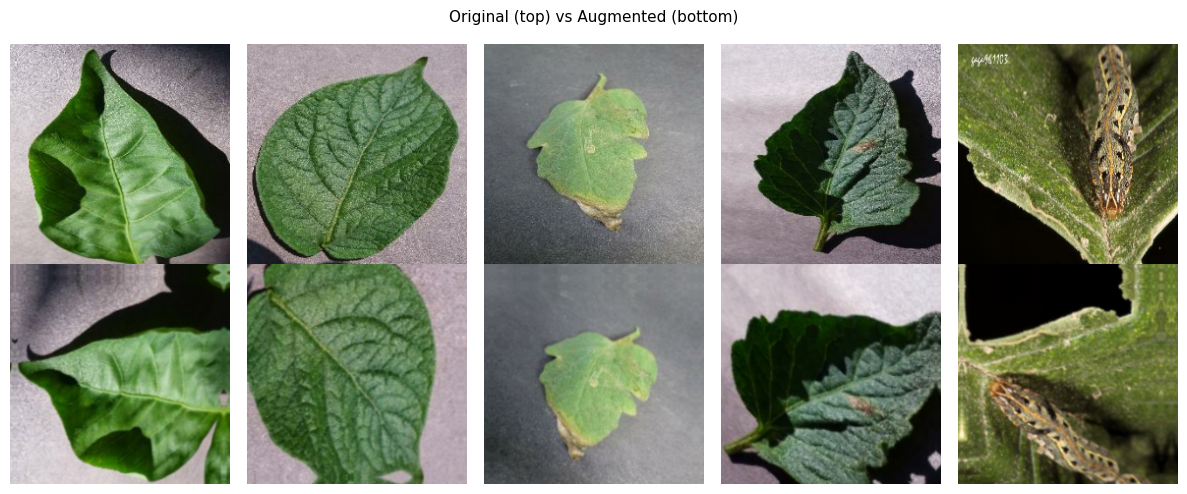

In [8]:
augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2),
  layers.RandomTranslation(0.1, 0.1),
], name='augmentation')

# Preview augmented images to verify it looks reasonable
sample_images, _ = next(iter(train_ds.take(1)))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Original (top) vs Augmented (bottom)', fontsize=11)
for i in range(5):
    img = sample_images[i].numpy().astype('uint8')
    aug = augmentation(tf.expand_dims(sample_images[i], 0), training=True)
    aug = aug[0].numpy().clip(0, 255).astype('uint8')
    axes[0][i].imshow(img);  axes[0][i].axis('off')
    axes[1][i].imshow(aug);  axes[1][i].axis('off')
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/augmentation_preview.png', dpi=100)
plt.show()

In [9]:
from tensorflow.keras import Model
from tensorflow.keras.applications import MobileNetV2

# Load base model — weights from ImageNet, no top classifier
base = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
)

# Freeze first 100 layers — keep low-level ImageNet features
base.trainable = True
for layer in base.layers[:100]:
    layer.trainable = False

frozen  = sum(1 for l in base.layers if not l.trainable)
unfrozen = sum(1 for l in base.layers if l.trainable)
print(f"Base model: {frozen} layers frozen, {unfrozen} layers trainable")

# Build full model
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = augmentation(inputs, training=True)          # augmentation in-graph
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)  # scale to [-1,1]
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.6)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs, name='irrigation_mobilenetv2')
model.summary(show_trainable=True)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model: 100 layers frozen, 54 layers trainable


Model: "irrigation_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ augmentation (Sequential)   │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ true_divide (TrueDivide)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ subtract (Subtract)         │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   Y   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 5)             │      6,405 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,867,845 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class names from the output directory, ensuring sorted order
CLASS_NAMES = sorted(os.listdir(OUTPUT_DIR))

# Collect all labels from train set
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(np.argmax(labels.numpy()))

all_labels = np.array(all_labels)
unique_classes = np.unique(all_labels)

weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=all_labels,
)

class_weight_dict = dict(zip(unique_classes, weights))
print("Class weights:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {name:<22}: {class_weight_dict[idx]:.3f}")

Class weights:
  Early_Blight          : 1.196
  Healthy               : 0.953
  Late_Blight           : 0.956
  Nutrient_Deficiency   : 0.961
  Pest                  : 0.973


In [11]:
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

CHECKPOINT_PATH = f'{DRIVE_BASE}/best_model.keras'

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    # Stop early if val_accuracy stops improving
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    # Save best model to Drive automatically
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
    # Reduce learning rate if stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("Starting training...")
print(f"Best model will be saved to: {CHECKPOINT_PATH}")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1,
)

Starting training...
Best model will be saved to: /content/drive/MyDrive/irrigation_ml/best_model.keras
Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6982 - loss: 0.8319
Epoch 1: val_accuracy improved from None to 0.73818, saving model to /content/drive/MyDrive/irrigation_ml/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/irrigation_ml/best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 125ms/step - accuracy: 0.8318 - loss: 0.4677 - val_accuracy: 0.7382 - val_loss: 1.2857 - learning_rate: 1.0000e-04
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9364 - loss: 0.1879
Epoch 2: val_accuracy improved from 0.73818 to 0.78294, saving model to /content/drive/MyDrive/irrigation_ml/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/irrigation_ml/best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 71s 105ms/step - accuracy: 0.9409 - loss: 0.1716 - val_accuracy: 0.7829 - val_loss: 1.0393 - learning_rate: 1.0000e-04

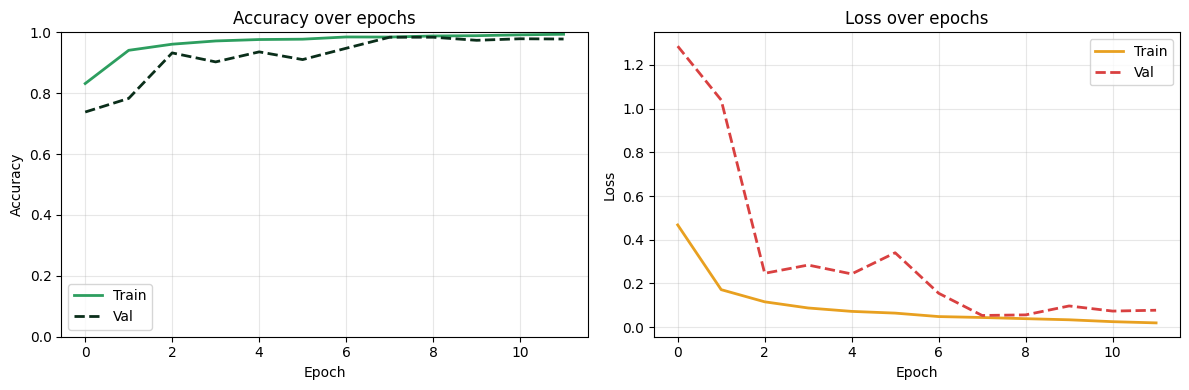

Final val accuracy: 0.978
Best  val accuracy: 0.984


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train', color='#2d9e5f', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val',   color='#0a2e1a', linewidth=2, linestyle='--')
ax1.set_title('Accuracy over epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_ylim(0, 1)

ax2.plot(history.history['loss'],     label='Train', color='#e8a020', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val',   color='#d94040', linewidth=2, linestyle='--')
ax2.set_title('Loss over epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/training_curves.png', dpi=120)
plt.show()

final_acc = history.history['val_accuracy'][-1]
best_acc  = max(history.history['val_accuracy'])
print(f"Final val accuracy: {final_acc:.3f}")
print(f"Best  val accuracy: {best_acc:.3f}")

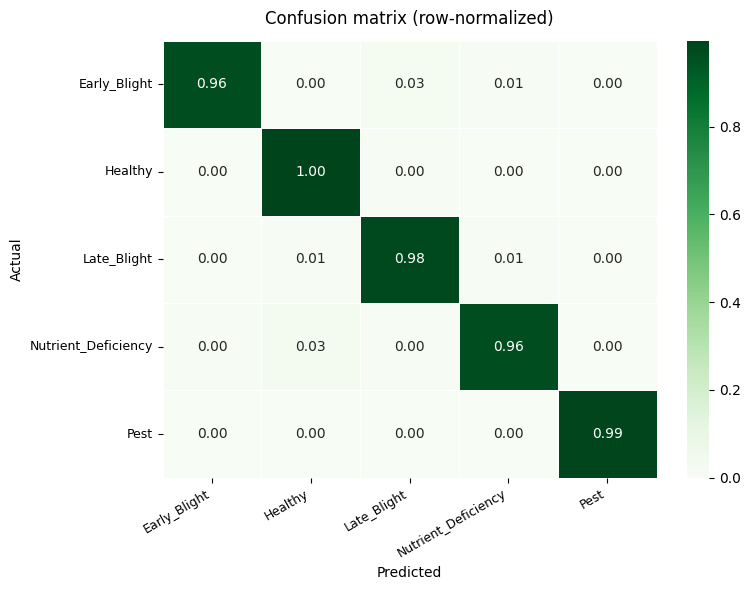


Classification report:
                     precision    recall  f1-score   support

       Early_Blight      0.989     0.963     0.976       189
            Healthy      0.960     0.996     0.978       244
        Late_Blight      0.970     0.981     0.976       264
Nutrient_Deficiency      0.979     0.963     0.971       243
               Pest      1.000     0.989     0.995       276

           accuracy                          0.979      1216
          macro avg      0.980     0.978     0.979      1216
       weighted avg      0.980     0.979     0.979      1216



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5)
ax.set_title('Confusion matrix (row-normalized)', fontsize=12, pad=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/confusion_matrix.png', dpi=120)
plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

In [14]:
import json

# Save class names so anyone loading the model knows the label order
with open(f'{DRIVE_BASE}/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)

# Save training history for later analysis
with open(f'{DRIVE_BASE}/training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals]
               for k, vals in history.history.items()}, f)

# Best model is already saved by ModelCheckpoint to best_model.keras
# Also save final model
model.save(f'{DRIVE_BASE}/final_model.keras')

print("Saved to Drive:")
print(f"  {DRIVE_BASE}/best_model.keras")
print(f"  {DRIVE_BASE}/final_model.keras")
print(f"  {DRIVE_BASE}/class_names.json")
print(f"  {DRIVE_BASE}/training_history.json")
print(f"  {DRIVE_BASE}/confusion_matrix.png")
print(f"  {DRIVE_BASE}/training_curves.png")

Saved to Drive:
  /content/drive/MyDrive/irrigation_ml/best_model.keras
  /content/drive/MyDrive/irrigation_ml/final_model.keras
  /content/drive/MyDrive/irrigation_ml/class_names.json
  /content/drive/MyDrive/irrigation_ml/training_history.json
  /content/drive/MyDrive/irrigation_ml/confusion_matrix.png
  /content/drive/MyDrive/irrigation_ml/training_curves.png


In [15]:
import gc
import tensorflow as tf

DRIVE_BASE  = '/content/drive/MyDrive/irrigation_ml'
OUTPUT_DIR  = '/content/dataset'
MODEL_PATH  = f'{DRIVE_BASE}/best_model.keras'
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42

# Rebuild val/test pool (same seed as training — identical split)
val_test_pool = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)

val_batches = len(val_test_pool) // 2
test_ds = val_test_pool.skip(val_batches).prefetch(tf.data.AUTOTUNE)
calib_ds = val_test_pool.take(val_batches).prefetch(tf.data.AUTOTUNE)  # no .cache()

# Baseline accuracy
model = tf.keras.models.load_model(MODEL_PATH)
_, keras_acc = model.evaluate(test_ds, verbose=1)
print(f"\nKeras float32 accuracy: {keras_acc:.4f}  ({keras_acc*100:.2f}%)")

# Free the Keras model before conversion — peak RAM halved
del model
gc.collect()
tf.keras.backend.clear_session()
print("Keras model freed from memory")

Found 12000 files belonging to 5 classes.
Using 2400 files for validation.
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9786 - loss: 0.0666

Keras float32 accuracy: 0.9786  (97.86%)
Keras model freed from memory


In [16]:
import os
import numpy as np

TFLITE_PATH   = f'{DRIVE_BASE}/irrigation_int8.tflite'
CALIB_BATCHES = 20   # 640 images; raise to 50 if RAM allows

def representative_dataset():
    count = 0
    for images, _ in calib_ds.take(CALIB_BATCHES):
        for img in images:
            yield [tf.expand_dims(img, axis=0)]
            count += 1
    print(f"Calibration samples: {count}")

# Reload model fresh just for conversion
model = tf.keras.models.load_model(MODEL_PATH)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations                = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset       = representative_dataset
converter.target_spec.supported_ops    = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type         = tf.int8
converter.inference_output_type        = tf.int8

tflite_model = converter.convert()

# Free immediately after conversion
del model
gc.collect()
tf.keras.backend.clear_session()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(TFLITE_PATH) / 1e6
print(f"Saved: {TFLITE_PATH}")
print(f"Size : {size_mb:.2f} MB  {'✓ PASS (<4 MB)' if size_mb < 4 else '✗ FAIL (>=4 MB)'}")

Saved artifact at '/tmp/tmpely77o2n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132490132993232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488692991376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488692991568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132489364525264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488692990416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488692991952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488692992144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488692991184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488692991760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488692992720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1324886929906

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Calibration samples: 640
Saved: /content/drive/MyDrive/irrigation_ml/irrigation_int8.tflite
Size : 2.71 MB  ✓ PASS (<4 MB)


In [17]:
import json

interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

inp  = interpreter.get_input_details()[0]
out  = interpreter.get_output_details()[0]
in_scale,  in_zp  = inp['quantization']
out_scale, out_zp = out['quantization']

print(f"Input  — scale={in_scale:.6f}  zero_point={in_zp}")
print(f"Output — scale={out_scale:.6f}  zero_point={out_zp}")

correct, total = 0, 0

for images, labels in test_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        img_int8 = np.round(img / in_scale + in_zp).clip(-128, 127).astype(np.int8)
        interpreter.set_tensor(inp['index'], img_int8[np.newaxis])
        interpreter.invoke()
        logits = (interpreter.get_tensor(out['index']).astype(np.float32) - out_zp) * out_scale
        correct += int(np.argmax(logits) == np.argmax(label))
        total   += 1

tflite_acc = correct / total
drop       = keras_acc - tflite_acc

print(f"\nKeras  accuracy : {keras_acc:.4f}  ({keras_acc*100:.2f}%)")
print(f"TFLite accuracy : {tflite_acc:.4f}  ({tflite_acc*100:.2f}%)")
print(f"Accuracy drop   : {drop*100:.2f} pp  {'✓ PASS (<2pp)' if drop < 0.02 else '✗ FAIL (>=2pp)'}")

# Save summary for the Pi daemon
summary = {
    'keras_accuracy' : float(keras_acc),
    'tflite_accuracy': float(tflite_acc),
    'accuracy_drop'  : float(drop),
    'model_size_mb'  : float(size_mb),
    'in_scale'       : float(in_scale),
    'in_zero_point'  : int(in_zp),
    'out_scale'      : float(out_scale),
    'out_zero_point' : int(out_zp),
    'img_size'       : IMG_SIZE,
    'num_classes'    : 5,
}
with open(f'{DRIVE_BASE}/tflite_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\nSummary saved → {DRIVE_BASE}/tflite_summary.json")

Input  — scale=1.000000  zero_point=-128
Output — scale=0.003906  zero_point=-128


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Keras  accuracy : 0.9786  (97.86%)
TFLite accuracy : 0.9704  (97.04%)
Accuracy drop   : 0.82 pp  ✓ PASS (<2pp)

Summary saved → /content/drive/MyDrive/irrigation_ml/tflite_summary.json


In [18]:
# Save the actual TFLite model file to your Drive/Destination
with open(f'{DRIVE_BASE}/model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Model saved successfully to → {DRIVE_BASE}/model.tflite")

Model saved successfully to → /content/drive/MyDrive/irrigation_ml/model.tflite


In [19]:
import struct, time
from dataclasses import dataclass
from enum import IntEnum
from typing import Optional

START_BYTE        = 0xAA
PACKET_LEN        = 8
HIGH_CONF         = 0.75
LOW_CONF          = 0.50
CLASS_NAMES       = ['Early_Blight', 'Healthy', 'Late_Blight',
                     'Nutrient_Deficiency', 'Pest']
CLASS_TO_PROTOCOL = {0: 0x01, 1: 0x00, 2: 0x01, 3: 0x02, 4: 0x03}

class ProtocolCode(IntEnum):
    NO_ACTION       = 0x00
    INCREASE_WATER  = 0x01
    DECREASE_WATER  = 0x02
    APPLY_PESTICIDE = 0x03
    ALERT_OPERATOR  = 0x04
    SYSTEM_ERROR    = 0x05

@dataclass
class Packet:
    protocol    : ProtocolCode
    class_index : int
    confidence  : float
    timestamp_s : int
    raw         : bytes
    def __repr__(self):
        name = CLASS_NAMES[self.class_index] if 0 <= self.class_index < len(CLASS_NAMES) else 'UNKNOWN'
        return (f"Packet(proto={self.protocol.name}, class={name}, "
                f"conf={self.confidence:.2f}, raw={self.raw.hex(' ').upper()})")

def build_packet(class_index: int, confidence: float,
                 timestamp_s: Optional[int] = None) -> Packet:
    if timestamp_s is None:
        timestamp_s = int(time.monotonic())
    ts = timestamp_s & 0xFFFF

    if class_index < 0 or class_index >= len(CLASS_NAMES):
        protocol   = ProtocolCode.SYSTEM_ERROR
        confidence = 0.0
    elif confidence < LOW_CONF:
        protocol = ProtocolCode.SYSTEM_ERROR
    elif confidence < HIGH_CONF:
        protocol = ProtocolCode.ALERT_OPERATOR
    else:
        protocol = ProtocolCode(CLASS_TO_PROTOCOL[class_index])

    conf_b = int(round(confidence * 255)) & 0xFF
    body   = bytes([START_BYTE, int(protocol), class_index & 0xFF, conf_b,
                    (ts >> 8) & 0xFF, ts & 0xFF, 0x00])
    xor    = 0
    for b in body: xor ^= b
    raw    = body + bytes([xor])
    return Packet(protocol, class_index, confidence, timestamp_s, raw)

def verify_checksum(raw: bytes) -> bool:
    if len(raw) != PACKET_LEN: return False
    xor = 0
    for b in raw[:-1]: xor ^= b
    return xor == raw[-1]

# Quick demo
print("Protocol demo:")
for label, cls, conf in [
    ("Healthy, high conf",             1, 0.92),
    ("Early_Blight, high conf",        0, 0.85),
    ("Late_Blight, high conf",         2, 0.80),
    ("Nutrient_Deficiency, high conf", 3, 0.77),
    ("Pest, high conf",                4, 0.96),
    ("Any class, medium conf",         1, 0.65),
    ("Any class, low conf",            2, 0.35),
]:
    print(f"  {label:<35} → {build_packet(cls, conf, timestamp_s=1000)}")

Protocol demo:
  Healthy, high conf                  → Packet(proto=NO_ACTION, class=Healthy, conf=0.92, raw=AA 00 01 EB 03 E8 00 AB)
  Early_Blight, high conf             → Packet(proto=INCREASE_WATER, class=Early_Blight, conf=0.85, raw=AA 01 00 D9 03 E8 00 99)
  Late_Blight, high conf              → Packet(proto=INCREASE_WATER, class=Late_Blight, conf=0.80, raw=AA 01 02 CC 03 E8 00 8E)
  Nutrient_Deficiency, high conf      → Packet(proto=DECREASE_WATER, class=Nutrient_Deficiency, conf=0.77, raw=AA 02 03 C4 03 E8 00 84)
  Pest, high conf                     → Packet(proto=APPLY_PESTICIDE, class=Pest, conf=0.96, raw=AA 03 04 F5 03 E8 00 B3)
  Any class, medium conf              → Packet(proto=ALERT_OPERATOR, class=Healthy, conf=0.65, raw=AA 04 01 A6 03 E8 00 E2)
  Any class, low conf                 → Packet(proto=SYSTEM_ERROR, class=Late_Blight, conf=0.35, raw=AA 05 02 59 03 E8 00 1F)


In [20]:
import unittest

class TestProtocol(unittest.TestCase):

    def _pkt(self, cls, conf):
        p = build_packet(cls, conf, timestamp_s=1000)
        self.assertTrue(verify_checksum(p.raw), f"Bad checksum: {p}")
        self.assertEqual(len(p.raw), 8)
        self.assertEqual(p.raw[0], 0xAA)
        return p

    # 0x00 NO_ACTION
    def test_00_healthy_high(self):
        self.assertEqual(self._pkt(1, 0.90).protocol, ProtocolCode.NO_ACTION)
    def test_00_exactly_threshold(self):
        self.assertEqual(self._pkt(1, HIGH_CONF).protocol, ProtocolCode.NO_ACTION)

    # 0x01 INCREASE_WATER
    def test_01_early_blight(self):
        self.assertEqual(self._pkt(0, 0.88).protocol, ProtocolCode.INCREASE_WATER)
    def test_01_late_blight(self):
        self.assertEqual(self._pkt(2, 0.82).protocol, ProtocolCode.INCREASE_WATER)

    # 0x02 DECREASE_WATER
    def test_02_nutrient_deficiency(self):
        self.assertEqual(self._pkt(3, 0.79).protocol, ProtocolCode.DECREASE_WATER)

    # 0x03 APPLY_PESTICIDE
    def test_03_pest(self):
        self.assertEqual(self._pkt(4, 0.95).protocol, ProtocolCode.APPLY_PESTICIDE)
    def test_03_full_confidence(self):
        p = self._pkt(4, 1.0)
        self.assertEqual(p.protocol, ProtocolCode.APPLY_PESTICIDE)
        self.assertEqual(p.raw[3], 255)

    # 0x04 ALERT_OPERATOR
    def test_04_medium_conf(self):
        self.assertEqual(self._pkt(1, 0.62).protocol, ProtocolCode.ALERT_OPERATOR)
    def test_04_pest_medium(self):
        self.assertEqual(self._pkt(4, 0.71).protocol, ProtocolCode.ALERT_OPERATOR)
    def test_04_just_below_high(self):
        self.assertEqual(self._pkt(0, 0.749).protocol, ProtocolCode.ALERT_OPERATOR)

    # 0x05 SYSTEM_ERROR
    def test_05_low_conf(self):
        self.assertEqual(self._pkt(1, 0.30).protocol, ProtocolCode.SYSTEM_ERROR)
    def test_05_zero_conf(self):
        self.assertEqual(self._pkt(1, 0.0).protocol, ProtocolCode.SYSTEM_ERROR)
    def test_05_invalid_class(self):
        self.assertEqual(self._pkt(99, 0.99).protocol, ProtocolCode.SYSTEM_ERROR)

    # Packet structure
    def test_8_bytes_all_protocols(self):
        for cls, conf in [(1,.90),(0,.88),(3,.80),(4,.95),(1,.62),(1,.30)]:
            self.assertEqual(len(build_packet(cls, conf, timestamp_s=500).raw), 8)

    def test_checksum_all_protocols(self):
        for cls, conf in [(1,.90),(0,.88),(3,.80),(4,.95),(1,.62),(1,.30)]:
            self.assertTrue(verify_checksum(build_packet(cls, conf, timestamp_s=500).raw))

    def test_timestamp_wrap(self):
        p = build_packet(1, 0.90, timestamp_s=65536)
        ts = (p.raw[4] << 8) | p.raw[5]
        self.assertEqual(ts, 0)

    def test_corrupt_raises(self):
        raw = bytearray(build_packet(1, 0.90, timestamp_s=100).raw)
        raw[3] ^= 0xFF
        xor = 0
        for b in raw[:-1]: xor ^= b
        self.assertNotEqual(xor, raw[-1])   # confirms corruption detected

suite = unittest.TestLoader().loadTestsFromTestCase(TestProtocol)
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)
print(f"\n{'ALL TESTS PASSED ✓' if result.wasSuccessful() else 'FAILURES DETECTED ✗'}")

test_00_exactly_threshold (__main__.TestProtocol.test_00_exactly_threshold) ... ok
test_00_healthy_high (__main__.TestProtocol.test_00_healthy_high) ... ok
test_01_early_blight (__main__.TestProtocol.test_01_early_blight) ... ok
test_01_late_blight (__main__.TestProtocol.test_01_late_blight) ... ok
test_02_nutrient_deficiency (__main__.TestProtocol.test_02_nutrient_deficiency) ... ok
test_03_full_confidence (__main__.TestProtocol.test_03_full_confidence) ... ok
test_03_pest (__main__.TestProtocol.test_03_pest) ... ok
test_04_just_below_high (__main__.TestProtocol.test_04_just_below_high) ... ok
test_04_medium_conf (__main__.TestProtocol.test_04_medium_conf) ... ok
test_04_pest_medium (__main__.TestProtocol.test_04_pest_medium) ... ok
test_05_invalid_class (__main__.TestProtocol.test_05_invalid_class) ... ok
test_05_low_conf (__main__.TestProtocol.test_05_low_conf) ... ok
test_05_zero_conf (__main__.TestProtocol.test_05_zero_conf) ... ok
test_8_bytes_all_protocols (__main__.TestProtocol


ALL TESTS PASSED ✓


**save this as pi_daemon.py, copy to Pi alongside the .tflite and class_names.json**

In [21]:
# ── Save this cell to a .py file for the Pi ──────────────────────────────────
pi_daemon_code = '''
import argparse, json, logging, os, signal, sys, time
from pathlib import Path
from typing import Optional
import numpy as np
from PIL import Image

try:
    import tflite_runtime.interpreter as tflite
except ImportError:
    import tensorflow as tf; tflite = tf.lite

try:
    import serial; HAS_SERIAL = True
except ImportError:
    HAS_SERIAL = False

try:
    from picamera2 import Picamera2; HAS_CAMERA = True
except ImportError:
    HAS_CAMERA = False

START_BYTE=0xAA; PACKET_LEN=8; HIGH_CONF=0.75; LOW_CONF=0.50
CLASS_NAMES=['Early_Blight','Healthy','Late_Blight','Nutrient_Deficiency','Pest']
CLASS_TO_PROTOCOL={0:0x01,1:0x00,2:0x01,3:0x02,4:0x03}
PROTO_NAMES={0:'NO_ACTION',1:'INCREASE_WATER',2:'DECREASE_WATER',
             3:'APPLY_PESTICIDE',4:'ALERT_OPERATOR',5:'SYSTEM_ERROR'}

logging.basicConfig(level=logging.INFO,
    format='%(asctime)s  %(levelname)-7s  %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    handlers=[logging.StreamHandler(sys.stdout),
              logging.FileHandler('/tmp/irrigation_daemon.log')])
log = logging.getLogger('daemon')

def build_packet(class_index, confidence, timestamp_s=None):
    if timestamp_s is None: timestamp_s = int(time.monotonic())
    ts = timestamp_s & 0xFFFF
    if class_index < 0 or class_index >= len(CLASS_NAMES):
        proto=0x05; confidence=0.0
    elif confidence < LOW_CONF: proto=0x05
    elif confidence < HIGH_CONF: proto=0x04
    else: proto=CLASS_TO_PROTOCOL.get(class_index,0x05)
    conf_b=int(round(confidence*255))&0xFF
    body=bytes([START_BYTE,proto,class_index&0xFF,conf_b,(ts>>8)&0xFF,ts&0xFF,0x00])
    xor=0
    for b in body: xor^=b
    return body+bytes([xor]), PROTO_NAMES.get(proto,'?')

def verify_checksum(raw):
    if len(raw)!=PACKET_LEN: return False
    xor=0
    for b in raw[:-1]: xor^=b
    return xor==raw[-1]

class Classifier:
    def __init__(self, model_path, summary_path=None):
        self.interp = tflite.Interpreter(model_path=model_path)
        self.interp.allocate_tensors()
        self.inp = self.interp.get_input_details()[0]
        self.out = self.interp.get_output_details()[0]
        self.in_scale,  self.in_zp  = self.inp["quantization"]
        self.out_scale, self.out_zp = self.out["quantization"]
        if summary_path and Path(summary_path).exists():
            s=json.load(open(summary_path))
            self.in_scale=s.get("in_scale",self.in_scale)
            self.in_zp=s.get("in_zero_point",self.in_zp)
            self.out_scale=s.get("out_scale",self.out_scale)
            self.out_zp=s.get("out_zero_point",self.out_zp)
        _,h,w,_=self.inp["shape"]; self.img_size=(w,h)
        log.info("Model loaded: %s  input=%s", model_path, self.inp["shape"])

    def predict(self, img):
        img = img.convert("RGB").resize(self.img_size, Image.BILINEAR)
        arr = np.array(img, dtype=np.float32)
        arr = np.round(arr/self.in_scale+self.in_zp).clip(-128,127).astype(np.int8)
        self.interp.set_tensor(self.inp["index"], arr[np.newaxis])
        self.interp.invoke()
        logits=(self.interp.get_tensor(self.out["index"]).astype(np.float32)-self.out_zp)*self.out_scale
        e=np.exp(logits-logits.max()); probs=(e/e.sum()).flatten()
        idx=int(np.argmax(probs)); return idx, float(probs[idx]), probs

class UARTWriter:
    def __init__(self, port, baud=9600, dry_run=False):
        self.dry_run=dry_run; self._ser=None
        if not dry_run:
            if not HAS_SERIAL: raise ImportError("pip install pyserial")
            self._ser=serial.Serial(port,baudrate=baud,timeout=1)
            log.info("UART: %s @ %d baud", port, baud)
    def send(self, raw):
        if not verify_checksum(raw): log.error("Bad checksum, not sending"); return False
        if self.dry_run: log.info("[DRY-RUN] %s", raw.hex(" ").upper()); return True
        try: return self._ser.write(raw)==PACKET_LEN
        except Exception as e: log.error("UART error: %s", e); return False
    def close(self):
        if self._ser and self._ser.is_open: self._ser.close()

def run(args):
    clf  = Classifier(args.model, summary_path=args.summary)
    uart = UARTWriter(args.uart, args.baud, dry_run=args.dry_run)
    boot = time.monotonic()
    running = [True]
    signal.signal(signal.SIGINT,  lambda *_: running.__setitem__(0, False))
    signal.signal(signal.SIGTERM, lambda *_: running.__setitem__(0, False))

    def process(img, label=""):
        ts = int(time.monotonic()-boot)
        try:
            idx, conf, probs = clf.predict(img)
        except Exception as e:
            log.error("Inference error: %s", e)
            pkt, _ = build_packet(-1, 0.0, ts); uart.send(pkt); return
        pkt, proto_name = build_packet(idx, conf, ts)
        name = CLASS_NAMES[idx] if 0<=idx<len(CLASS_NAMES) else f"class_{idx}"
        log.info("%-25s pred=%-22s conf=%.3f proto=%s", label or "frame", name, conf, proto_name)
        log.debug("  packet: %s", pkt.hex(" ").upper())
        uart.send(pkt)

    if args.image:
        process(Image.open(args.image), Path(args.image).name)
    elif args.watch:
        watch = Path(args.watch); done = watch/"done"; done.mkdir(exist_ok=True)
        log.info("Watching: %s", watch); seen = set()
        while running[0]:
            for p in sorted(watch.glob("*")):
                if not running[0]: break
                if p.suffix.lower() not in (".jpg",".jpeg",".png"): continue
                if p in seen: continue
                try: process(Image.open(p), p.name); seen.add(p); p.rename(done/p.name)
                except Exception as e: log.error("%s: %s", p.name, e)
            time.sleep(0.5)
    else:
        if not HAS_CAMERA: sys.exit("picamera2 not installed; use --image or --watch")
        cam = Picamera2()
        cam.configure(cam.create_still_configuration(main={"size":(640,480),"format":"RGB888"}))
        cam.start(); time.sleep(1.5)
        log.info("Camera loop started (interval=%ds)", args.interval)
        while running[0]:
            t0=time.monotonic()
            try: process(Image.fromarray(cam.capture_array()))
            except Exception as e: log.error("Capture error: %s", e)
            elapsed=time.monotonic()-t0
            deadline=time.monotonic()+max(0,args.interval-elapsed)
            while running[0] and time.monotonic()<deadline: time.sleep(0.1)
        cam.stop()
    uart.close()

if __name__=="__main__":
    p=argparse.ArgumentParser()
    p.add_argument("--model",    required=True)
    p.add_argument("--classes",  required=True)
    p.add_argument("--summary",  default=None)
    p.add_argument("--uart",     default="/dev/ttyAMA0")
    p.add_argument("--baud",     type=int, default=9600)
    p.add_argument("--dry-run",  action="store_true")
    p.add_argument("--image",    default=None)
    p.add_argument("--watch",    default=None)
    p.add_argument("--interval", type=int, default=10)
    run(p.parse_args())
'''

# Write to Drive so you can scp it to the Pi
daemon_path = f'{DRIVE_BASE}/pi_daemon.py'
with open(daemon_path, 'w') as f:
    f.write(pi_daemon_code.strip())
print(f"Saved → {daemon_path}")
print("\nCopy to Pi:")
print(f"  scp your-laptop:{daemon_path} pi@raspberrypi.local:~/irrigation/")
print("\nRun on Pi:")
print("  python3 pi_daemon.py --model irrigation_int8.tflite \\")
print("                       --classes class_names.json \\")
print("                       --uart /dev/ttyAMA0 --interval 10")
print("\nDry-run test:")
print("  python3 pi_daemon.py --model irrigation_int8.tflite \\")
print("                       --classes class_names.json \\")
print("                       --image leaf.jpg --dry-run")

Saved → /content/drive/MyDrive/irrigation_ml/pi_daemon.py

Copy to Pi:
  scp your-laptop:/content/drive/MyDrive/irrigation_ml/pi_daemon.py pi@raspberrypi.local:~/irrigation/

Run on Pi:
  python3 pi_daemon.py --model irrigation_int8.tflite \
                       --classes class_names.json \
                       --uart /dev/ttyAMA0 --interval 10

Dry-run test:
  python3 pi_daemon.py --model irrigation_int8.tflite \
                       --classes class_names.json \
                       --image leaf.jpg --dry-run
